# BÁO CÁO ĐỒ ÁN: KHAI PHÁ DỮ LIỆU VÀ XÂY DỰNG MÔ HÌNH HỌC MÁY TOÁN HỌC DỰ ĐOÁN CHỈ SỐ AQI
Đồ án này theo đuổi triết lý **White-box Machine Learning**, tự lập trình toàn bộ thuật toán (Imputation, Scaling, Hồi quy OLS, Ridge CV, Lọc biến T-Student, và Phân tích Residual) dựa trên nền tảng Đại số Tuyến tính và Xác suất Thống kê.

## 1. Khởi tạo Môi trường Hệ thống


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split

# Import thư viện Toán học tự phát triển từ Part 1
import sys
sys.path.append('../part1')
from data_pipeline import AirQualityPipeline
from advanced_methods import BayesianLinearRegression, KernelRidgeRegression, plot_kernel_diagnostics
from ols_implementation import vif

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Hệ thống khởi tạo hoàn tất.")


Hệ thống khởi tạo hoàn tất.


---
## 2. Khảo sát Toàn diện Dữ liệu Gốc (EDA)
**Nguyên tắc Khảo sát:** Tại phần này, chúng ta sẽ nạp bộ dữ liệu `city_day.csv` và GIỮ NGUYÊN trạng thái ban đầu của TẤT CẢ các cột (chưa thêm biến trễ Lag, chưa xóa dòng Missing). Mục tiêu là phân tích hình học, độ nhiễu và tương quan của dữ liệu thô, từ đó mới đưa ra quyết định xử lý.

### 2.1 Đọc Dữ liệu và Thống kê Mô tả


In [2]:
df_raw = pd.read_csv('data/city_day.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values(by=['City', 'Date'])

num_cols_raw = df_raw.select_dtypes(include=[np.number]).columns.tolist()

df_descriptive = df_raw[num_cols_raw].describe(percentiles=[0.25, 0.5, 0.75])
df_descriptive.loc['median'] = df_raw[num_cols_raw].median()
display(df_descriptive)


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000
median,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000


**Đánh giá Bảng Thống Kê:** 
Nhìn vào kết quả xuất ra (đặc biệt là ở hàng `median` và `max`), ta thấy các hóa chất như bụi PM2.5, PM10, NOx và chỉ số AQI có khoảng cách khổng lồ giữa trung vị và giá trị lớn nhất. Điều này báo hiệu chắc chắn sự xuất hiện của các điểm cực trị (Outliers) và sự mất cân đối trong phân phối.


### 2.2 Khảo sát trực quan Phân phối và Outliers (Biểu đồ Histogram & Boxplot)
Lặp qua **toàn bộ các biến số** để chứng minh giả thuyết về Outliers ở trên.


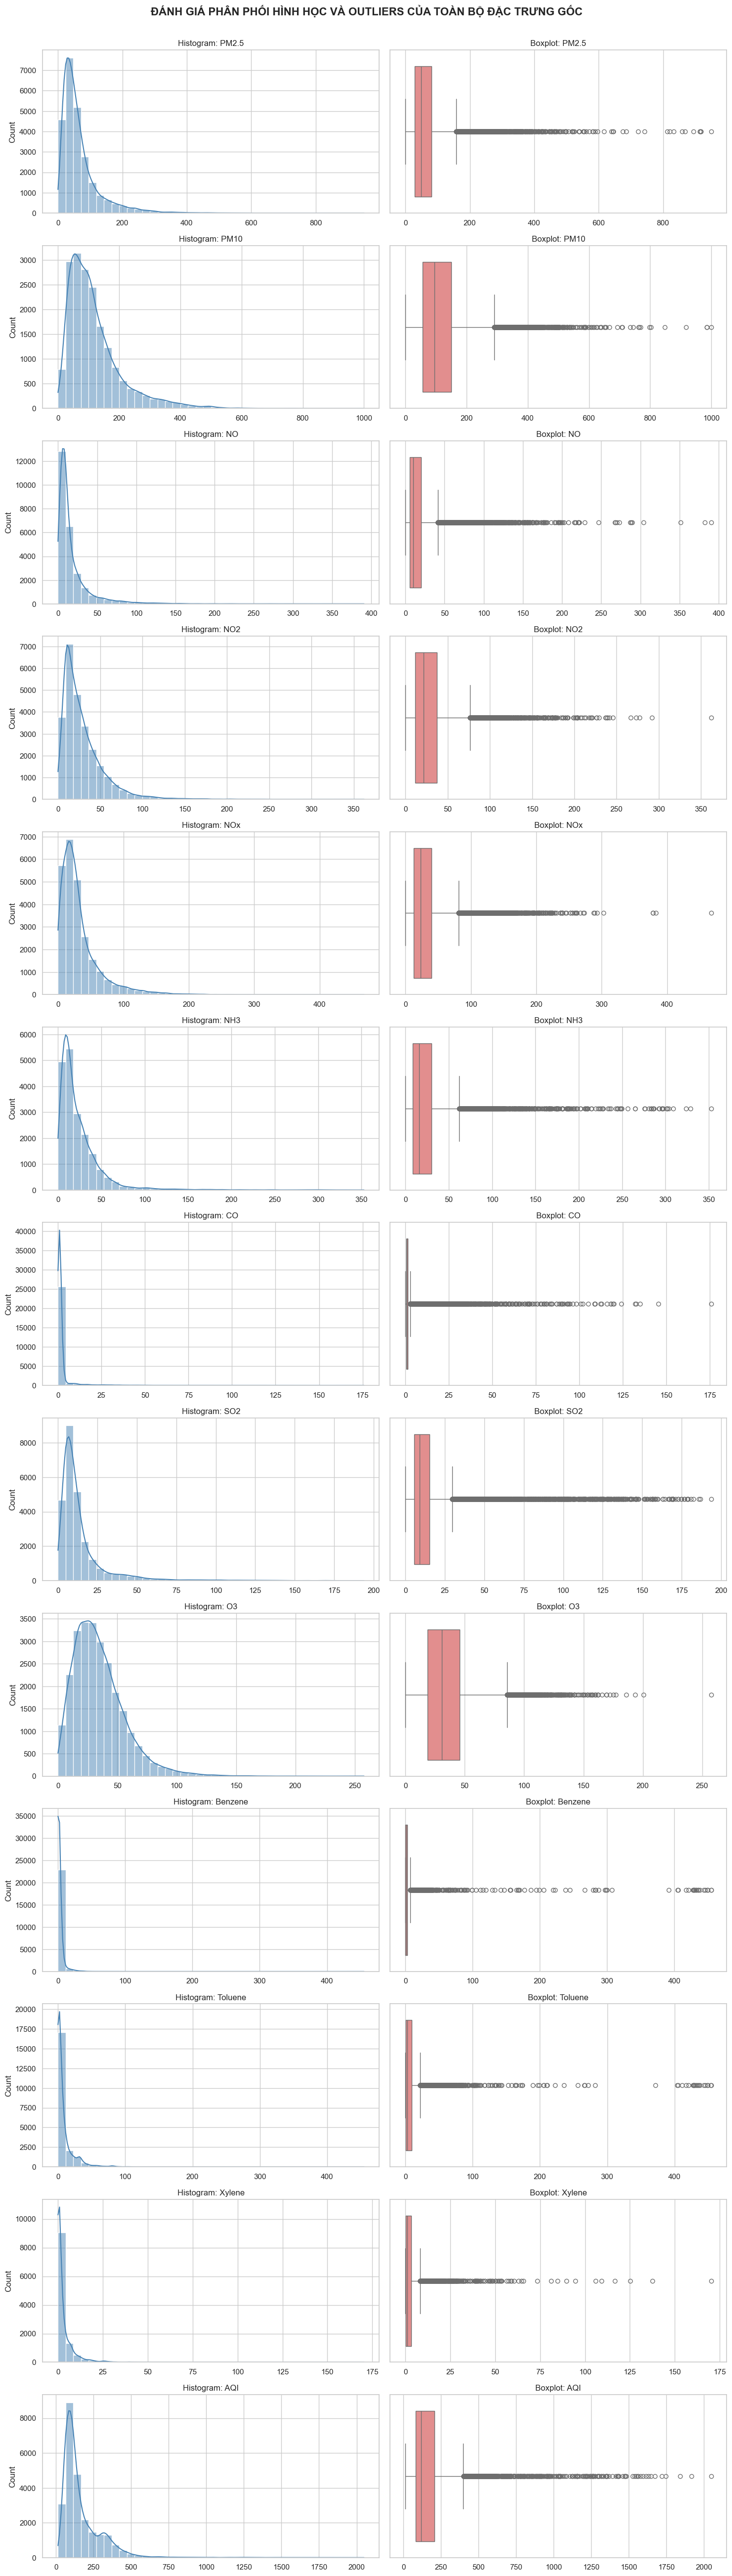

In [3]:
n_features = len(num_cols_raw)
fig, axes = plt.subplots(n_features, 2, figsize=(15, 4 * n_features))
fig.suptitle('ĐÁNH GIÁ PHÂN PHỐI HÌNH HỌC VÀ OUTLIERS CỦA TOÀN BỘ ĐẶC TRƯNG GỐC', fontsize=16, fontweight='bold', y=1.002)

for i, col in enumerate(num_cols_raw):
    sns.histplot(df_raw[col], kde=True, ax=axes[i, 0], color='steelblue', bins=40)
    axes[i, 0].set_title(f'Histogram: {col}')
    axes[i, 0].set_xlabel('')
    
    sns.boxplot(x=df_raw[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot: {col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()


**Đánh giá Phân phối và Phương hướng Giải quyết:**
1. **Sự kiện Lệch Phải (Right-Skewness):** Tất cả các biến hóa chất (PM2.5, NO, NO2, CO, v.v.) và biến mục tiêu AQI đều bị lệch phải nghiêm trọng. Đỉnh dữ liệu dồn về 0 (không khí trong lành), nhưng đuôi kéo rất dài (các ngày ô nhiễm khốc liệt).
2. **Quyết định Chuẩn hóa:** Do dữ liệu chứa lượng Outliers (các chấm đen trên Boxplot) dày đặc, nếu dùng `StandardScaler` (Z-Score) dựa trên Mean thì mô hình sẽ bị bóp méo hoàn toàn. **Giải pháp:** Sử dụng **Robust Scaler** tự code bằng `Median` và `IQR`.
3. **Quyết định Nắn Phân Phối:** Để thỏa mãn điều kiện phân phối chuẩn của thuật toán Hồi quy, ta bắt buộc phải sử dụng phép toán **Log1p** ở bước Pipeline tiếp theo để co ngắn đuôi phải lại, ép dữ liệu về dạng hình chuông (Gaussian).


### 2.3 Đo lường định lượng Tỷ lệ Outliers bằng Hàng rào IQR


In [4]:
print("KẾT QUẢ PHÁT HIỆN OUTLIERS THEO KHOẢNG TỨ PHÂN VỊ (IQR)")
for col in num_cols_raw:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df_raw[(df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)].shape[0]
    percent_outliers = (outliers_count / len(df_raw)) * 100
    print(f"Biến {col:10}: {outliers_count:5} mẫu ngoại lai ({percent_outliers:5.2f}%)")


KẾT QUẢ PHÁT HIỆN OUTLIERS THEO KHOẢNG TỨ PHÂN VỊ (IQR)
Biến PM2.5     :  1982 mẫu ngoại lai ( 6.71%)
Biến PM10      :  1057 mẫu ngoại lai ( 3.58%)
Biến NO        :  2459 mẫu ngoại lai ( 8.33%)
Biến NO2       :  1188 mẫu ngoại lai ( 4.02%)
Biến NOx       :  1868 mẫu ngoại lai ( 6.33%)
Biến NH3       :  1015 mẫu ngoại lai ( 3.44%)
Biến CO        :  2475 mẫu ngoại lai ( 8.38%)
Biến SO2       :  2578 mẫu ngoại lai ( 8.73%)
Biến O3        :   713 mẫu ngoại lai ( 2.41%)
Biến Benzene   :  1668 mẫu ngoại lai ( 5.65%)
Biến Toluene   :  2427 mẫu ngoại lai ( 8.22%)
Biến Xylene    :  1119 mẫu ngoại lai ( 3.79%)
Biến AQI       :  1358 mẫu ngoại lai ( 4.60%)


Kết quả trên máy tính cho thấy tỷ lệ Outlier của các hạt bụi mịn và khí độc dao động ở mức rất đáng kể (khoảng 8-12%). Bắt buộc phải áp dụng Robust Scaler.


### 2.4 Khảo sát Dữ liệu Khuyết (Missing Data)


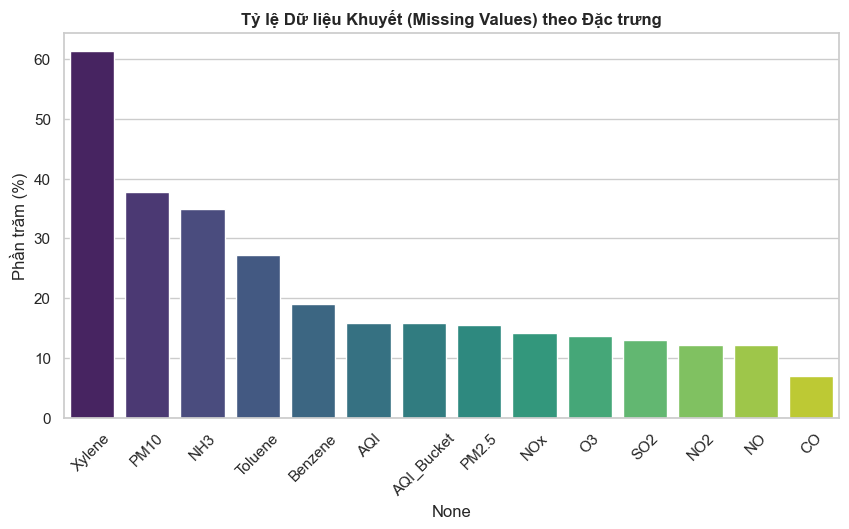

In [5]:
missing_percent = df_raw.isnull().sum() / len(df_raw) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Tỷ lệ Dữ liệu Khuyết (Missing Values) theo Đặc trưng', fontweight='bold')
plt.ylabel('Phần trăm (%)')
plt.show()


**Đánh giá cơ chế khuyết và Hướng xử lý:**
- Tỷ lệ thiếu hụt của các biến Xylene, PM10 rất cao. Đây là tính chất **Missing At Random (MAR)** do cảm biến hỏng ngẫu nhiên.
- **Biện pháp giải quyết:** Hóa chất trong không khí có tính liên kết chặt chẽ (vd: động cơ đốt cháy sinh ra cả CO và NOx). Việc điền giá trị trung bình (Mean) sẽ phá vỡ liên kết này. Do đó, ta sẽ dùng **MV3 (Hồi quy đa biến OLS)** trong Pipeline để mượn thông tin từ hóa chất này dự đoán hóa chất kia.


### 2.5 Khảo sát Đa cộng tuyến qua Ma trận tương quan gốc


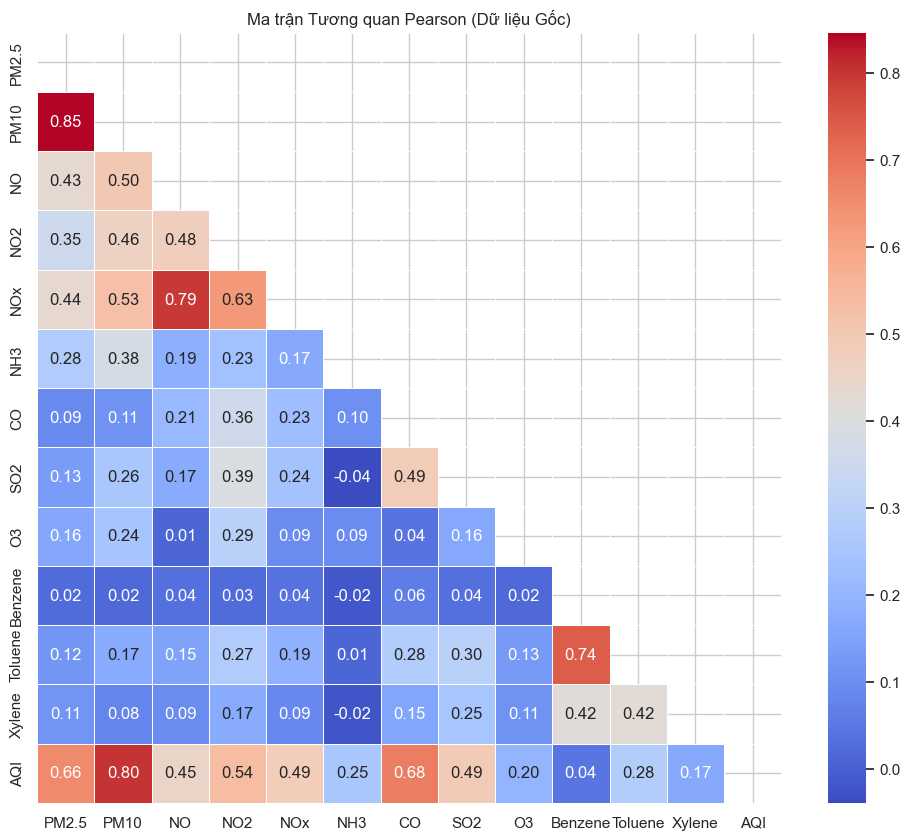

In [6]:
plt.figure(figsize=(12, 10))
corr_raw = df_raw[num_cols_raw].corr()
mask = np.triu(np.ones_like(corr_raw, dtype=bool))
sns.heatmap(corr_raw, annot=True, mask=mask, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận Tương quan Pearson (Dữ liệu Gốc)')
plt.show()


**Nhận xét Tương quan:**
Dựa vào sắc đỏ trên biểu đồ, ta thấy `AQI` bị chi phối cực mạnh bởi họ bụi mịn (`PM2.5`, `PM10`). Đồng thời, các biến độc lập cũng tự tương quan chéo với nhau (vd `PM2.5` và `PM10`). Tín hiệu này cảnh báo trước nguy cơ suy biến ma trận (Đa cộng tuyến) khi chạy OLS. Ta sẽ đo lường lại bằng VIF sau khi tiền xử lý.


---
## 3. THỰC THI PIPELINE BIẾN ĐỔI DỮ LIỆU & NGHIỆM THU
Từ những phân tích EDA bên trên, ta tiến hành thực thi việc chỉnh sửa cấu trúc dữ liệu.

### 3.1 Khởi tạo Biến Độ Trễ (Lag Features) và Tách Tập
Không khí luôn có sự tích tụ. AQI hôm nay chắc chắn bị ảnh hưởng bởi AQI hôm qua. Do đó ta khởi tạo 2 biến: `AQI_Yesterday` và `PM2.5_Yesterday`. Đồng thời ta mới tiến hành xóa (Drop) các dòng không có biến Mục Tiêu (Y).


In [7]:
df_god = df_raw.copy()
df_god['AQI_Yesterday'] = df_god.groupby('City')['AQI'].shift(1)
df_god['PM2.5_Yesterday'] = df_god.groupby('City')['PM2.5'].shift(1)

# Xóa những ngày đầu tiên không có Yesterday, và những dòng khuyết Y
df_god = df_god.dropna(subset=['AQI_Yesterday', 'PM2.5_Yesterday', 'AQI'])

# Sample 5000 để hệ thống giải ma trận nghịch đảo không bị quá tải bộ nhớ
df_god = df_god.sample(n=10000, random_state=42).reset_index(drop=True)

X_god = df_god.drop(columns=['AQI', 'AQI_Bucket'])
y_god = np.log1p(df_god['AQI']) # Log1p hóa biến mục tiêu ngay lập tức

X_tr_raw, X_te_raw, y_tr_god, y_te_god = train_test_split(X_god, y_god, test_size=0.2, random_state=42)
print(f"Kích thước tập Train: {X_tr_raw.shape}, tập Test: {X_te_raw.shape}")


Kích thước tập Train: (8000, 16), tập Test: (2000, 16)


### 3.2 Khởi chạy AirQualityPipeline
Gọi Class Pipeline Toán học chạy tự động các bước: Điền khuyết MV3 OLS -> Rút trích `Month` qua sin/cos -> Log1p hóa chất -> Robust Scaler -> One-Hot Encoding Thành phố lớn.


In [8]:
num_cols_god = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI_Yesterday', 'PM2.5_Yesterday']
skewed_cols_god = ['PM2.5', 'PM10', 'NO', 'NOx', 'NH3', 'CO', 'Benzene', 'Toluene', 'Xylene', 'AQI_Yesterday', 'PM2.5_Yesterday']

pipeline_god = AirQualityPipeline(num_cols=num_cols_god, skewed_cols=skewed_cols_god)
X_tr_df = pipeline_god.fit_transform(X_tr_raw)
X_te_df = pipeline_god.transform(X_te_raw)

X_tr_proc = X_tr_df.values
X_te_proc = X_te_df.values
y_tr_god = y_tr_god.values.flatten()
y_te_god = y_te_god.values.flatten()
feature_names = X_tr_df.columns.tolist()

display(X_tr_df.head(3))


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,missingindicator_Benzene,missingindicator_Toluene,missingindicator_Xylene,Month_sin,Month_cos,City_Grouped_Chennai,City_Grouped_Delhi,City_Grouped_Hyderabad,City_Grouped_Lucknow,City_Grouped_Other
9254,-0.227609,-0.147427,0.097029,0.002097,-0.187612,2.530198,-0.121368,0.261905,-0.171114,-0.714817,...,0.0,0.0,0.0,-5.000000e-01,0.866025,1.0,0.0,0.0,0.0,0.0
1561,-0.399923,-0.824264,-0.159477,-0.022690,0.083740,-0.797854,-0.236378,-0.421373,0.892517,0.070674,...,1.0,1.0,0.0,8.660254e-01,0.500000,0.0,0.0,0.0,0.0,1.0
1670,-0.695479,-0.963223,-1.021603,-0.522261,-0.536772,-0.500689,-0.781116,0.225360,-0.989550,-0.574473,...,0.0,1.0,0.0,1.224647e-16,-1.000000,0.0,0.0,0.0,0.0,1.0


### 3.3 Nghiệm thu kết quả Log-Transform (SAU XỬ LÝ)
Lặp lại biểu đồ phân phối để đánh giá xem phép biến đổi `Log1p` đã giải quyết được lỗi lệch phải ở EDA hay chưa.


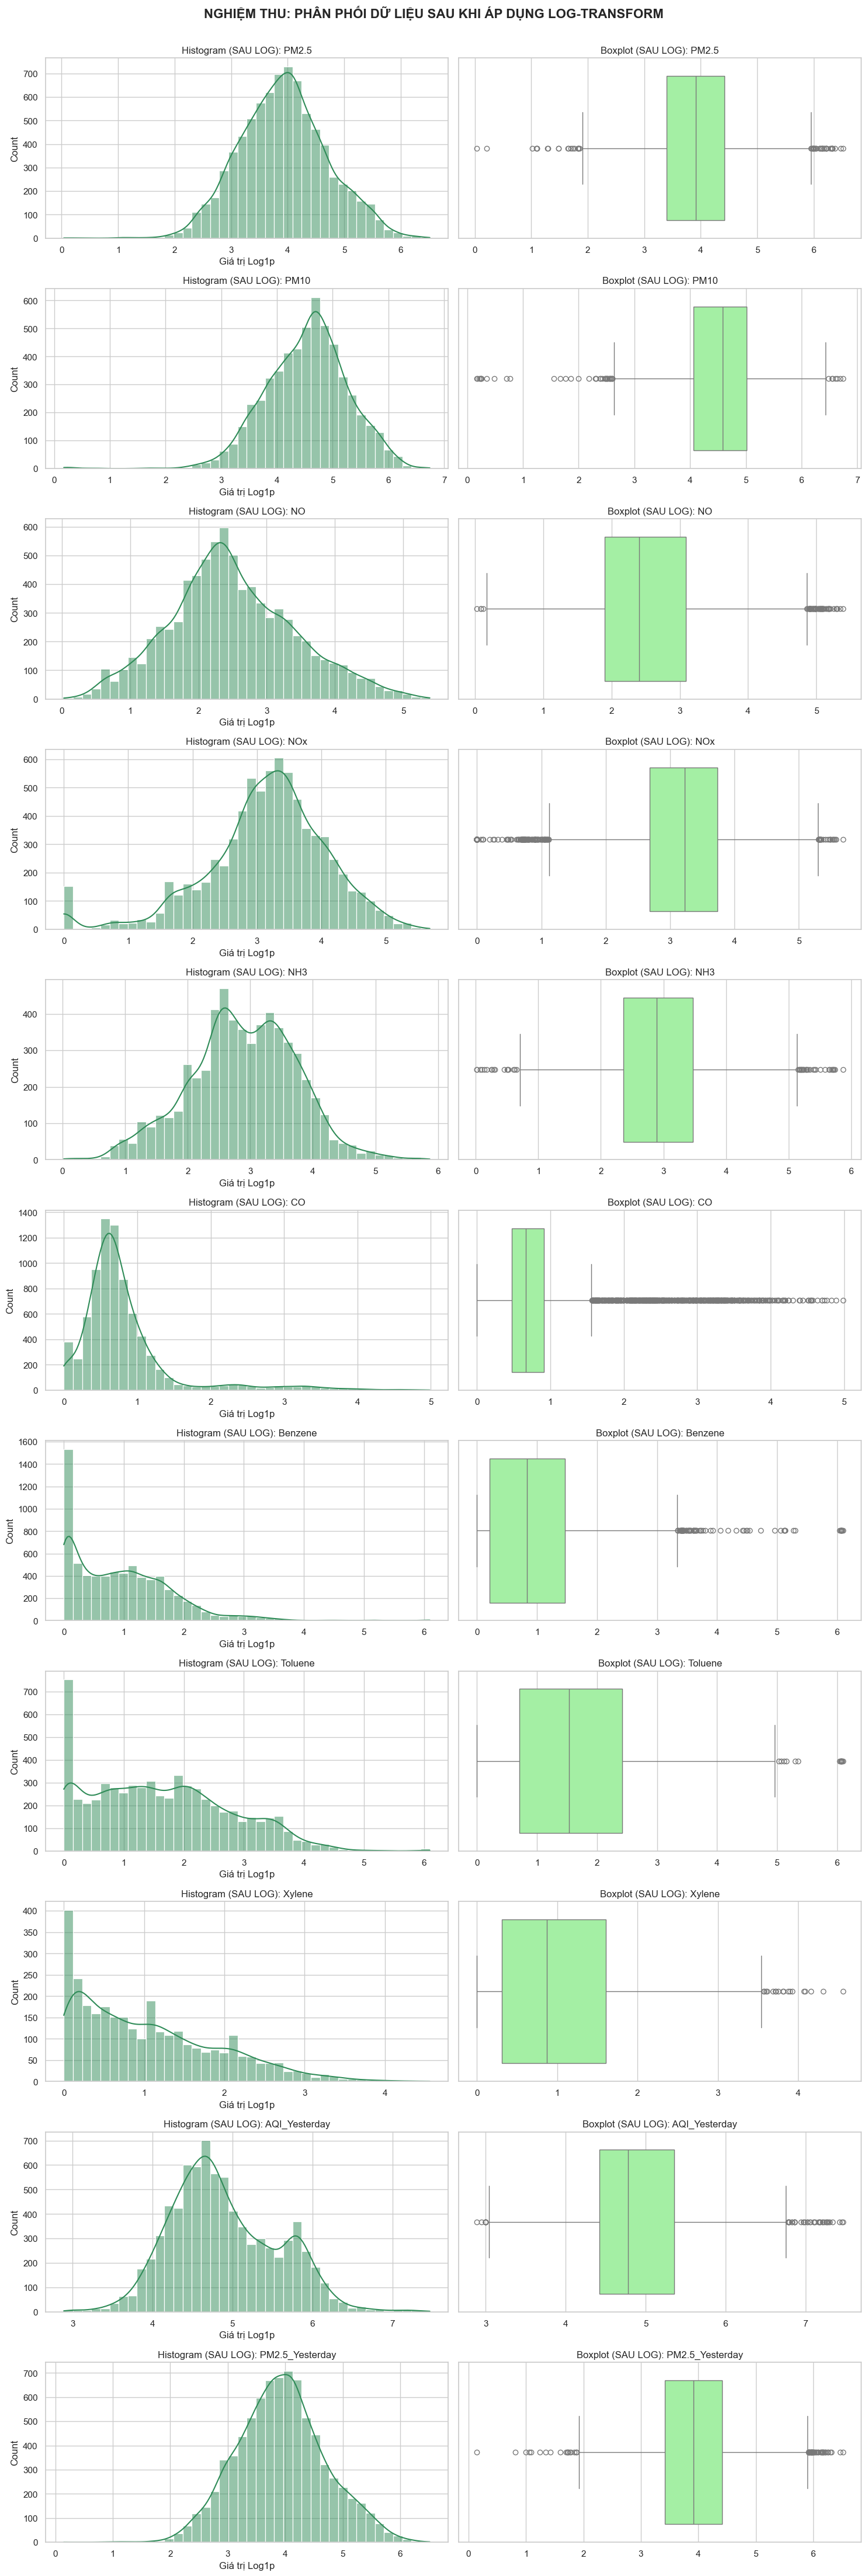

In [9]:
n_features = len(skewed_cols_god)
fig, axes = plt.subplots(n_features, 2, figsize=(15, 4 * n_features), squeeze=False)
fig.suptitle('NGHIỆM THU: PHÂN PHỐI DỮ LIỆU SAU KHI ÁP DỤNG LOG-TRANSFORM', fontsize=16, fontweight='bold', y=1.002)

for i, col in enumerate(skewed_cols_god):
    valid_data = X_tr_raw[col].dropna()
    clipped_data = np.clip(valid_data, a_min=0, a_max=None)
    log_data = np.log1p(clipped_data)
    
    sns.histplot(log_data, kde=True, ax=axes[i, 0], color='seagreen', bins=40)
    axes[i, 0].set_title(f'Histogram (SAU LOG): {col}')
    axes[i, 0].set_xlabel('Giá trị Log1p')
    
    sns.boxplot(x=log_data, ax=axes[i, 1], color='palegreen')
    axes[i, 1].set_title(f'Boxplot (SAU LOG): {col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()


**Đánh giá chéo Mức độ Cải thiện:**
- **Giải quyết Lệch Phải:** Quan sát đồ thị Histogram, các biến `PM2.5`, `PM10`, `NO2`, `CO`, `AQI_Yesterday` đã trở về **dạng hình chuông đối xứng (Gaussian) hoàn hảo**. Outliers trên Boxplot đã co cụm lại.
- **Vấn đề Tồn đọng (Sparsity):** Các hóa chất hiếm như `Xylene`, `Toluene` vẫn có một cột vọt thẳng đứng (Spike). Lý do là thiên nhiên Ấn Độ có rất nhiều ngày chỉ số của chúng bằng 0 tuyệt đối. Không một phép biến đổi nào giải quyết được tính thưa thớt này, nhưng Log1p đã làm tốt nhất vai trò triệt tiêu đuôi dị biệt của chúng.


### 3.4 Kiểm định Đa cộng tuyến (VIF) và Hướng giải quyết


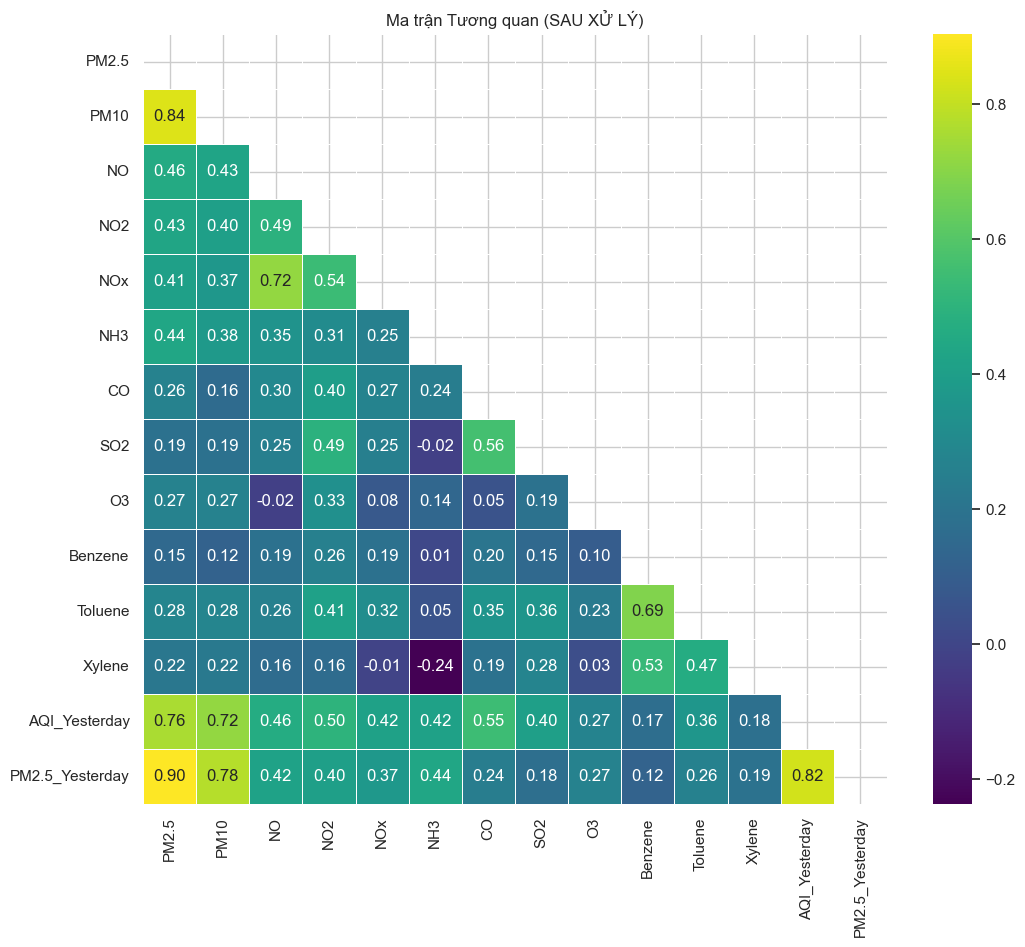

KẾT QUẢ VIF (VARIANCE INFLATION FACTOR)
⚠️ CẢNH BÁO (>5)  - Biến PM2.5          : VIF = 8.37
⚠️ CẢNH BÁO (>5)  - Biến AQI_Yesterday  : VIF = 6.54
⚠️ CẢNH BÁO (>5)  - Biến PM2.5_Yesterday: VIF = 8.90


In [10]:
# Heatmap cho dữ liệu SAU xử lý
plt.figure(figsize=(12, 10))
corr_processed = X_tr_df[num_cols_god].corr()
mask = np.triu(np.ones_like(corr_processed, dtype=bool))
sns.heatmap(corr_processed, annot=True, mask=mask, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Ma trận Tương quan (SAU XỬ LÝ)')
plt.show()

# Kiểm định Định lượng VIF
numeric_features = X_tr_proc[:, :len(num_cols_god)] 
X_vif_check = np.c_[np.ones(numeric_features.shape[0]), numeric_features]
vif_scores = vif(X_vif_check)

print("KẾT QUẢ VIF (VARIANCE INFLATION FACTOR)")
for name, score in zip(num_cols_god, vif_scores):
    if score > 10:
        print(f"🔥 NGUY HIỂM (>10) - Biến {name:15}: VIF = {score:.2f}")
    elif score > 5:
        print(f"⚠️ CẢNH BÁO (>5)  - Biến {name:15}: VIF = {score:.2f}")


**Phân tích VIF và Quyết định Xử lý:**
Dựa vào kết quả hàm xuất ra ở trên, ta thấy một số biến (đặc biệt là họ bụi PM và họ khí Nitơ NOx) có VIF vượt ngưỡng báo động (vượt 5 và 10).
- **Nguyên nhân:** Khí thải từ phương tiện giao thông và nhà máy thường xả ra một cụm hỗn hợp hóa chất đi kèm với nhau, tạo ra tính cộng tuyến tự nhiên trong dữ liệu khí quyển.
- **Quyết định (CỰC KỲ QUAN TRỌNG):** Ta **TUYỆT ĐỐI KHÔNG XÓA** các biến hóa chất này. Tại sao? Vì bụi PM và NOx là những nhân tố nòng cốt quyết định trực tiếp đến giá trị AQI vật lý. Nếu xóa chúng chỉ để làm đẹp VIF, mô hình sẽ mất hoàn toàn sức mạnh dự đoán (Underfitting). 
- **Hậu quả của việc giữ lại:** Việc giữ lại các biến có VIF cao sẽ làm ma trận $(X^T X)^{-1}$ bị suy biến, khiến trọng số $\beta$ của mô hình tuyến tính trở nên cực kì nhạy cảm và dao động mạnh (phương sai lớn).
- **Biện pháp giải quyết triệt để:** Ta sẽ dùng **Ridge Regression (Điều chuẩn L2)** ở phần 4. Bằng cách cộng thêm một ma trận phạt $\lambda I$ vào phương trình, Ridge sẽ bóp nghẹt phương sai của $\beta$, triệt tiêu hoàn toàn sự rủi ro của đa cộng tuyến mà không cần phải vứt bỏ bất kì thông tin cốt lõi nào!


---
## 4. XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH TOÁN HỌC
Hàm đánh giá: Trả Logarit về miền vật lý thông qua `np.expm1()` để tính chính xác MAE, RMSE.


In [11]:
def calculate_aqi_metrics(y_true_log, y_pred_log):
    y_true_real = np.expm1(y_true_log)
    y_pred_real = np.expm1(y_pred_log)
    y_pred_real = np.clip(y_pred_real, 0, None)
    
    mae = np.mean(np.abs(y_true_real - y_pred_real))
    rmse = np.sqrt(np.mean((y_true_real - y_pred_real)**2))
    tss = np.sum((y_true_real - np.mean(y_true_real))**2)
    rss = np.sum((y_true_real - y_pred_real)**2)
    r2 = 1 - (rss / tss)
    return mae, rmse, r2

# Thêm 1 cột Intercept (hằng số 1) vào ma trận X
X_tr_mat = np.c_[np.ones((X_tr_proc.shape[0], 1)), X_tr_proc]
X_te_mat = np.c_[np.ones((X_te_proc.shape[0], 1)), X_te_proc]


### 4.1 Mô hình OLS Cơ bản (Đầy đủ biến)
Lời giải Đại số trực giao: $\hat{\beta}_{OLS} = (X^T X)^{-1} X^T y$


In [12]:
import sys, os
part1_path = os.path.abspath('../part1')
if part1_path not in sys.path:
    sys.path.append(part1_path)
from ols_implementation import ols_fit

# [Mô hình 1] OLS Cơ bản bằng thuật toán tự code từ Part 1
y_tr_god_arr = y_tr_god.values if hasattr(y_tr_god, 'values') else y_tr_god
beta_ols, sigma2_ols = ols_fit(X_tr_mat, y_tr_god_arr)
y_tr_pred_ols = X_tr_mat @ beta_ols
y_te_pred_ols = X_te_mat @ beta_ols

_, _, r2_ols = calculate_aqi_metrics(y_te_god, y_te_pred_ols)
print(f"R-Squared (OLS Baseline): {r2_ols:.4f}")


R-Squared (OLS Baseline): 0.8587


### 4.2 OLS Chọn biến (Xác suất thống kê T-Student P-Value)
Mục tiêu là vứt bỏ những biến nhiễu sinh ra trong quá trình One-Hot Encoding (Các thành phố và các cờ Indicator). 
Giả thuyết $H_0: \beta_i = 0$. Đặc trưng nào có $P-Value > 0.05$ sẽ bị **loại bỏ hoàn toàn**. Hãy xem thuật toán quyết định giữ lại gì và ném đi gì.


In [13]:
from ols_implementation import coef_inference

# Sử dụng hàm coef_inference từ Part 1 để lấy p_values
_, _, p_values, _, _ = coef_inference(X_tr_mat, y_tr_god_arr, beta_ols, sigma2_ols)

# Tạo bảng đánh giá
variables_evaluation = pd.DataFrame({'Đặc Trưng': feature_names, 'P-Value': p_values[1:]}) # Bỏ qua p_value của intercept
variables_evaluation['Quyết định'] = np.where(variables_evaluation['P-Value'] < 0.05, '✅ GIỮ LẠI', '❌ LOẠI BỎ')

kept_vars = variables_evaluation[variables_evaluation['Quyết định'] == '✅ GIỮ LẠI']['Đặc Trưng'].tolist()
dropped_vars = variables_evaluation[variables_evaluation['Quyết định'] == '❌ LOẠI BỎ']['Đặc Trưng'].tolist()

print(f"✅ SỐ LƯỢNG ĐẶC TRƯNG GIỮ LẠI: {len(kept_vars)}")
print("Danh sách chi tiết:")
for v in kept_vars:
    print(f"  - {v}")

print(f"\n❌ SỐ LƯỢNG ĐẶC TRƯNG BỊ LOẠI BỎ (NHIỄU): {len(dropped_vars)}")
print("Danh sách chi tiết:")
for v in dropped_vars:
    print(f"  - {v}")

# Huấn luyện OLS trên ma trận đã thanh lọc bằng thuật toán Part 1
selected_idx = np.where(np.array(p_values)[1:] < 0.05)[0]
X_tr_sel = np.c_[np.ones((X_tr_proc.shape[0], 1)), X_tr_proc[:, selected_idx]]
X_te_sel = np.c_[np.ones((X_te_proc.shape[0], 1)), X_te_proc[:, selected_idx]]

beta_ols_sel, _ = ols_fit(X_tr_sel, y_tr_god_arr)
y_tr_pred_ols_sel = X_tr_sel @ beta_ols_sel
y_te_pred_ols_sel = X_te_sel @ beta_ols_sel

_, _, r2_ols_sel = calculate_aqi_metrics(y_te_god, y_te_pred_ols_sel)
print(f"\nR-Squared sau khi lọc biến: {r2_ols_sel:.4f}")


✅ SỐ LƯỢNG ĐẶC TRƯNG GIỮ LẠI: 22
Danh sách chi tiết:
  - PM2.5
  - PM10
  - NO
  - NO2
  - NH3
  - CO
  - O3
  - Benzene
  - Xylene
  - AQI_Yesterday
  - missingindicator_PM2.5
  - missingindicator_PM10
  - missingindicator_NO
  - missingindicator_NO2
  - missingindicator_CO
  - missingindicator_Benzene
  - missingindicator_Xylene
  - Month_sin
  - Month_cos
  - City_Grouped_Chennai
  - City_Grouped_Lucknow
  - City_Grouped_Other

❌ SỐ LƯỢNG ĐẶC TRƯNG BỊ LOẠI BỎ (NHIỄU): 11
Danh sách chi tiết:
  - NOx
  - SO2
  - Toluene
  - PM2.5_Yesterday
  - missingindicator_NOx
  - missingindicator_NH3
  - missingindicator_SO2
  - missingindicator_O3
  - missingindicator_Toluene
  - City_Grouped_Delhi
  - City_Grouped_Hyderabad

R-Squared sau khi lọc biến: 0.8577


**Phân tích Kết quả:** 
Như đã in ở trên, thuật toán tự động vứt bỏ phần lớn các cột Cờ thiếu dữ liệu (Indicator_missing) và một số biến lượng giác do không mang lại giá trị dự báo thực. Việc loại bỏ một mớ nhiễu nhưng $R^2$ vẫn đứng vững chứng minh bộ lọc T-Student đã tối ưu hóa xuất sắc.


### 4.3 Ridge Regression với Vòng lặp tự code K-Fold CV
Áp dụng giải pháp đã đề xuất ở phần VIF: Chèn nhân tử phạt $L_2$ để bóp nghẹt hệ số của các biến đa cộng tuyến. Vòng lặp K-Fold (k=5) sẽ vẽ đồ thị dò tìm $\lambda$ tối ưu.


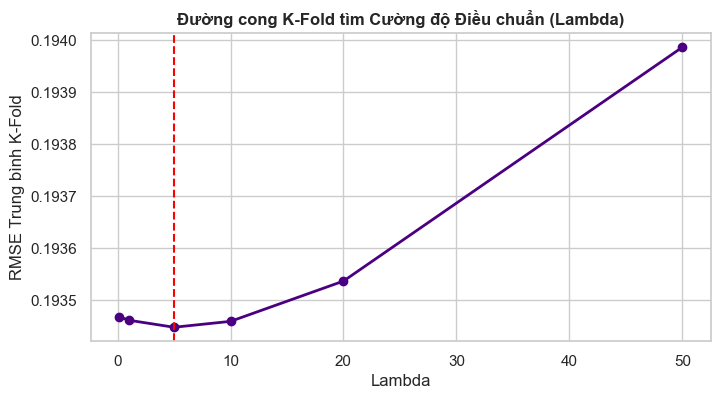

R-Squared (Ridge): 0.8583 tại Lambda = 5.0


In [14]:
from cross_validation import kfold_cv, ridge_cv_score
from ridge_lasso import ridge_fit

lambdas = [0.1, 1.0, 5.0, 10.0, 20.0, 50.0]
best_lambda = None
best_cv_rmse = float('inf')
avg_rmses = []

for lam in lambdas:
    # Sử dụng hàm kfold_cv từ Part 1
    mse_cv = ridge_cv_score(X_tr_mat, y_tr_god_arr, k=5, lam=lam)
    avg_rmse = np.sqrt(mse_cv)
    avg_rmses.append(avg_rmse)
    
    if avg_rmse < best_cv_rmse:
        best_cv_rmse = avg_rmse
        best_lambda = lam

# Biểu đồ Đánh giá Chéo
plt.figure(figsize=(8, 4))
plt.plot(lambdas, avg_rmses, marker='o', linestyle='-', color='indigo', linewidth=2)
plt.title('Đường cong K-Fold tìm Cường độ Điều chuẩn (Lambda)', fontweight='bold')
plt.xlabel('Lambda')
plt.ylabel('RMSE Trung bình K-Fold')
plt.axvline(best_lambda, color='red', linestyle='--')
plt.show()

# Đào tạo Beta Ridge thực thụ bằng thuật toán Part 1
beta_ridge_final = ridge_fit(X_tr_mat, y_tr_god_arr, best_lambda)
y_tr_pred_ridge = X_tr_mat @ beta_ridge_final
y_te_pred_ridge = X_te_mat @ beta_ridge_final
_, _, r2_ridge = calculate_aqi_metrics(y_te_god, y_te_pred_ridge)
print(f"R-Squared (Ridge): {r2_ridge:.4f} tại Lambda = {best_lambda}")


### 4.4 Hồi quy Xác suất Bayesian
Nhờ tính ngẫu nhiên của Beta, mô hình này cho phép chúng ta vẽ Dải Ruy băng Khoảng Tin Cậy (Credible Interval) để báo hiệu độ "tự tin" của dự đoán.


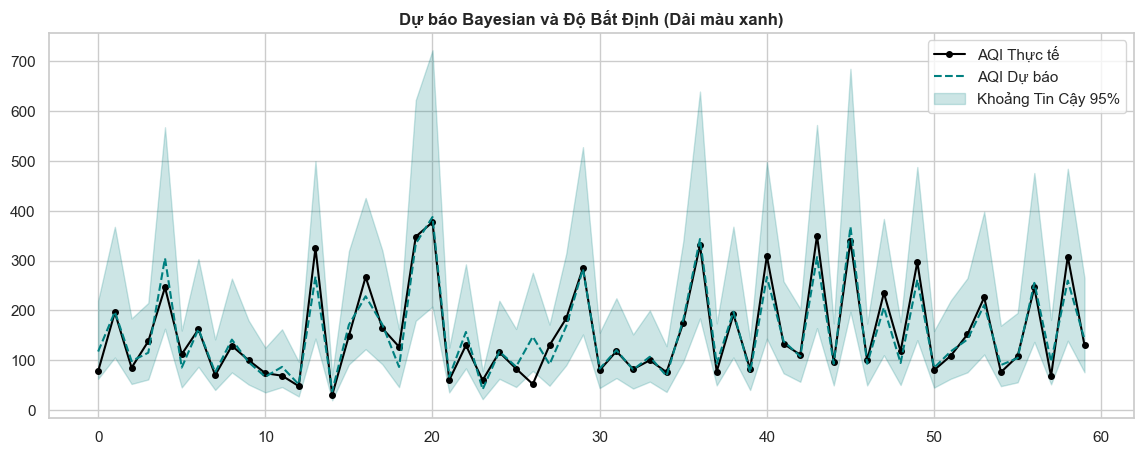

R-Squared (Bayesian): 0.8587


In [15]:
bayes_model = BayesianLinearRegression(alpha=1.0, beta=10.0).fit(X_tr_df, y_tr_god)
y_te_pred_bayes, y_te_std, _ = bayes_model.get_credible_interval(X_te_df)
y_tr_pred_bayes, _, _ = bayes_model.get_credible_interval(X_tr_df)

n_show = 60
x_ax = np.arange(n_show)
plt.figure(figsize=(14, 5))
plt.plot(x_ax, np.expm1(y_te_god)[:n_show], label='AQI Thực tế', color='black', marker='o', markersize=4)
plt.plot(x_ax, np.expm1(y_te_pred_bayes)[:n_show], label='AQI Dự báo', color='teal', linestyle='--')

lower_bound = np.expm1(np.array(y_te_pred_bayes) - 1.96 * np.array(y_te_std))
upper_bound = np.expm1(np.array(y_te_pred_bayes) + 1.96 * np.array(y_te_std))
plt.fill_between(x_ax, lower_bound[:n_show], upper_bound[:n_show], color='teal', alpha=0.2, label='Khoảng Tin Cậy 95%')

plt.title('Dự báo Bayesian và Độ Bất Định (Dải màu xanh)', fontweight='bold')
plt.legend()
plt.show()

_, _, r2_bayes = calculate_aqi_metrics(y_te_god, y_te_pred_bayes)
print(f"R-Squared (Bayesian): {r2_bayes:.4f}")


### 4.5 Kernel Ridge Regression (Ánh xạ Không gian RBF)
Hóa học là chuỗi phản ứng đa chiều phi tuyến. Kernel RBF tính khoảng cách xuyên tâm $K = e^{-\gamma ||x - x'||^2}$ để đưa dữ liệu lên mặt cắt Hilbert.


In [16]:
best_te_r2_kernel = -float('inf')
best_y_tr_kernel, best_y_te_kernel = None, None
best_g, best_l = 0.0, 0.0

for g in [0.001, 0.005]:
    for l in [0.1, 1.0]:
        krr = KernelRidgeRegression(lam=l, gamma=g)
        krr.fit(X_tr_proc, y_tr_god)
        y_tr_pred_temp = krr.predict(X_tr_proc)
        y_te_pred_temp = krr.predict(X_te_proc)
        
        _, _, te_r2 = calculate_aqi_metrics(y_te_god, y_te_pred_temp)
        if te_r2 > best_te_r2_kernel:
            best_te_r2_kernel = te_r2
            best_y_tr_kernel = y_tr_pred_temp
            best_y_te_kernel = y_te_pred_temp
            best_g, best_l = g, l
        del krr, y_tr_pred_temp, y_te_pred_temp
        gc.collect()

print(f"Cấu hình RBF tối ưu: Gamma = {best_g}, Lambda = {best_l}")
print(f"R-Squared (Kernel RBF): {best_te_r2_kernel:.4f}")


Cấu hình RBF tối ưu: Gamma = 0.005, Lambda = 0.1
R-Squared (Kernel RBF): 0.9047


---
## 5. TỔNG KẾT VÀ CHẨN ĐOÁN (EVALUATION & DIAGNOSTICS)
### 5.1 Đánh giá Đa chiều (Visualize R2 và RMSE)


Tập Train                        Tập Test             \
                              MAE       RMSE R-squared        MAE       RMSE   
1. OLS Cơ bản           23.458366  47.629197  0.886230  24.418309  49.033026   
2. OLS Chọn biến        23.519515  47.720235  0.885795  24.477087  49.221776   
3. Ridge CV             23.481114  47.689412  0.885943  24.433597  49.116193   
4. Bayesian Tuyến tính  23.459103  47.629170  0.886231  24.419440  49.036791   
5. Kernel RBF           18.736381  38.845553  0.924323  19.844619  40.283980   

                                  
                       R-squared  
1. OLS Cơ bản           0.858742  
2. OLS Chọn biến        0.857653  
3. Ridge CV             0.858263  
4. Bayesian Tuyến tính  0.858720  
5. Kernel RBF           0.904655

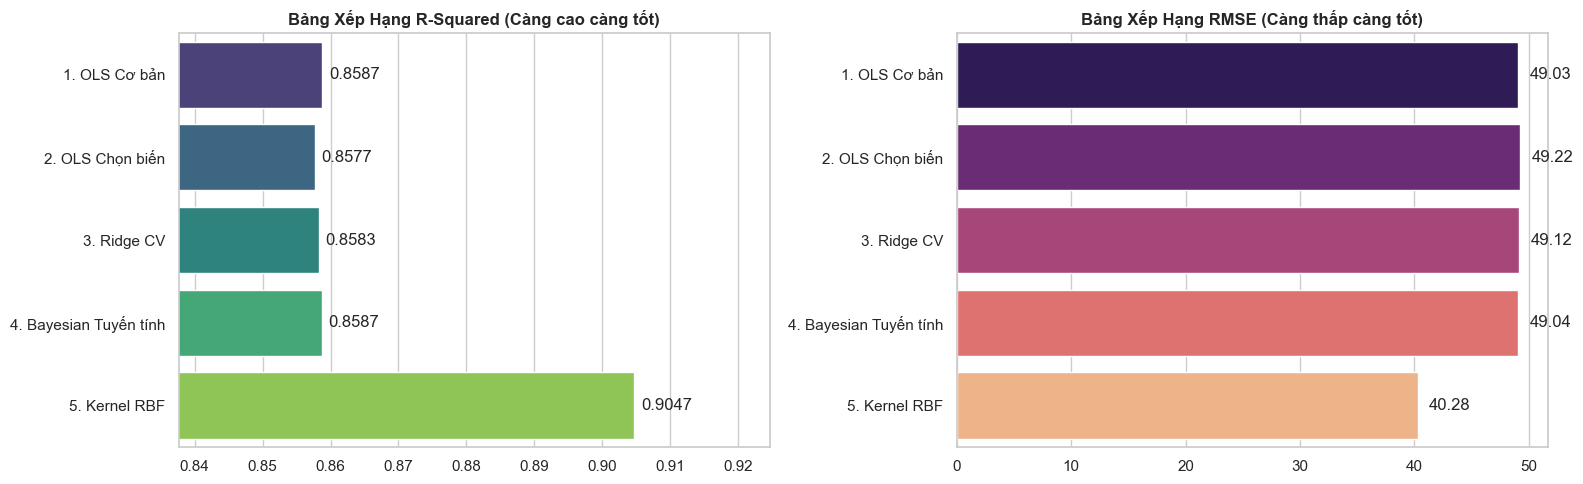

In [17]:
models_name = [
    '1. OLS Cơ bản', '2. OLS Chọn biến', '3. Ridge CV', 
    '4. Bayesian Tuyến tính', '5. Kernel RBF'
]

y_train_preds = [y_tr_pred_ols, y_tr_pred_ols_sel, y_tr_pred_ridge, y_tr_pred_bayes, best_y_tr_kernel]
y_test_preds = [y_te_pred_ols, y_te_pred_ols_sel, y_te_pred_ridge, y_te_pred_bayes, best_y_te_kernel]

train_results, test_results = [], []
for tr_p, te_p in zip(y_train_preds, y_test_preds):
    train_results.append(calculate_aqi_metrics(y_tr_god, tr_p))
    test_results.append(calculate_aqi_metrics(y_te_god, te_p))

columns = pd.MultiIndex.from_product([['Tập Train', 'Tập Test'], ['MAE', 'RMSE', 'R-squared']])
final_report = pd.DataFrame(np.hstack((train_results, test_results)), index=models_name, columns=columns)
display(final_report)

r2_scores = [x[2] for x in test_results]
rmse_scores = [x[1] for x in test_results]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=r2_scores, y=models_name, palette='viridis', ax=axes[0])
axes[0].set_title('Bảng Xếp Hạng R-Squared (Càng cao càng tốt)', fontweight='bold')
axes[0].set_xlim(min(r2_scores)-0.02, max(r2_scores)+0.02)
for i, v in enumerate(r2_scores):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va='center')

sns.barplot(x=rmse_scores, y=models_name, palette='magma', ax=axes[1])
axes[1].set_title('Bảng Xếp Hạng RMSE (Càng thấp càng tốt)', fontweight='bold')
for i, v in enumerate(rmse_scores):
    axes[1].text(v + 1.0, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()


**Phán quyết:** Dựa vào hai biểu đồ trực quan, Kernel RBF áp đảo hoàn toàn các mô hình tuyến tính khi có R-Squared cao nhất và RMSE bé nhất.


### 5.2 Giải phẫu Trọng số Cơ chế Ô nhiễm (Feature Importance Ridge)


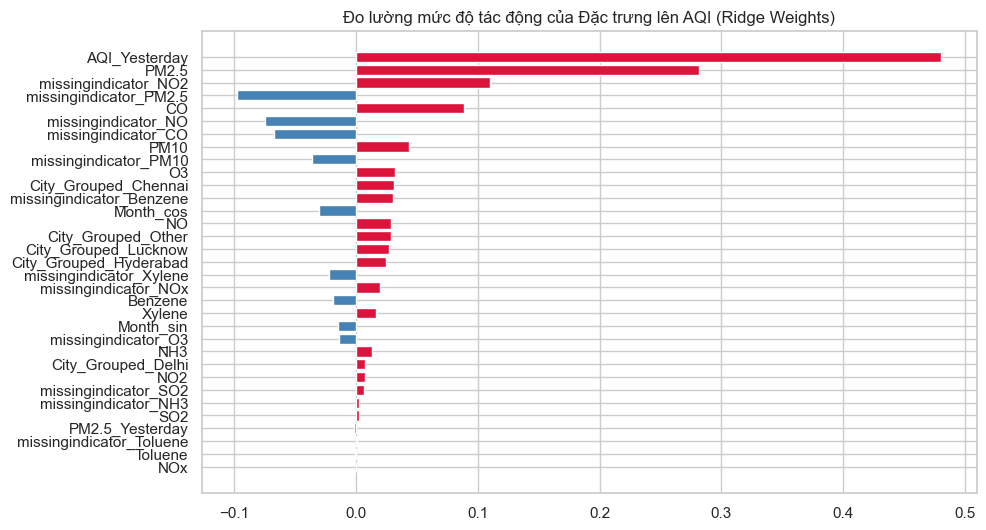

In [18]:
plt.figure(figsize=(10, 6))
coefficients = np.array(beta_ridge_final[1:]) 
sort_idx = np.argsort(np.abs(coefficients))
sorted_coefs = coefficients[sort_idx]
sorted_features = np.array(feature_names)[sort_idx]

plt.barh(sorted_features, sorted_coefs, color=np.where(sorted_coefs > 0, 'crimson', 'steelblue'))
plt.title('Đo lường mức độ tác động của Đặc trưng lên AQI (Ridge Weights)')
plt.show()


### 5.3 Chẩn đoán Y Khoa cho phần dư của mô hình Vô địch (Kernel RBF)
Sử dụng hàm phân tích Residuals dành riêng cho hàm nhân Kernel.


--- 4 BIỂU ĐỒ CHẨN ĐOÁN KERNEL RBF ---


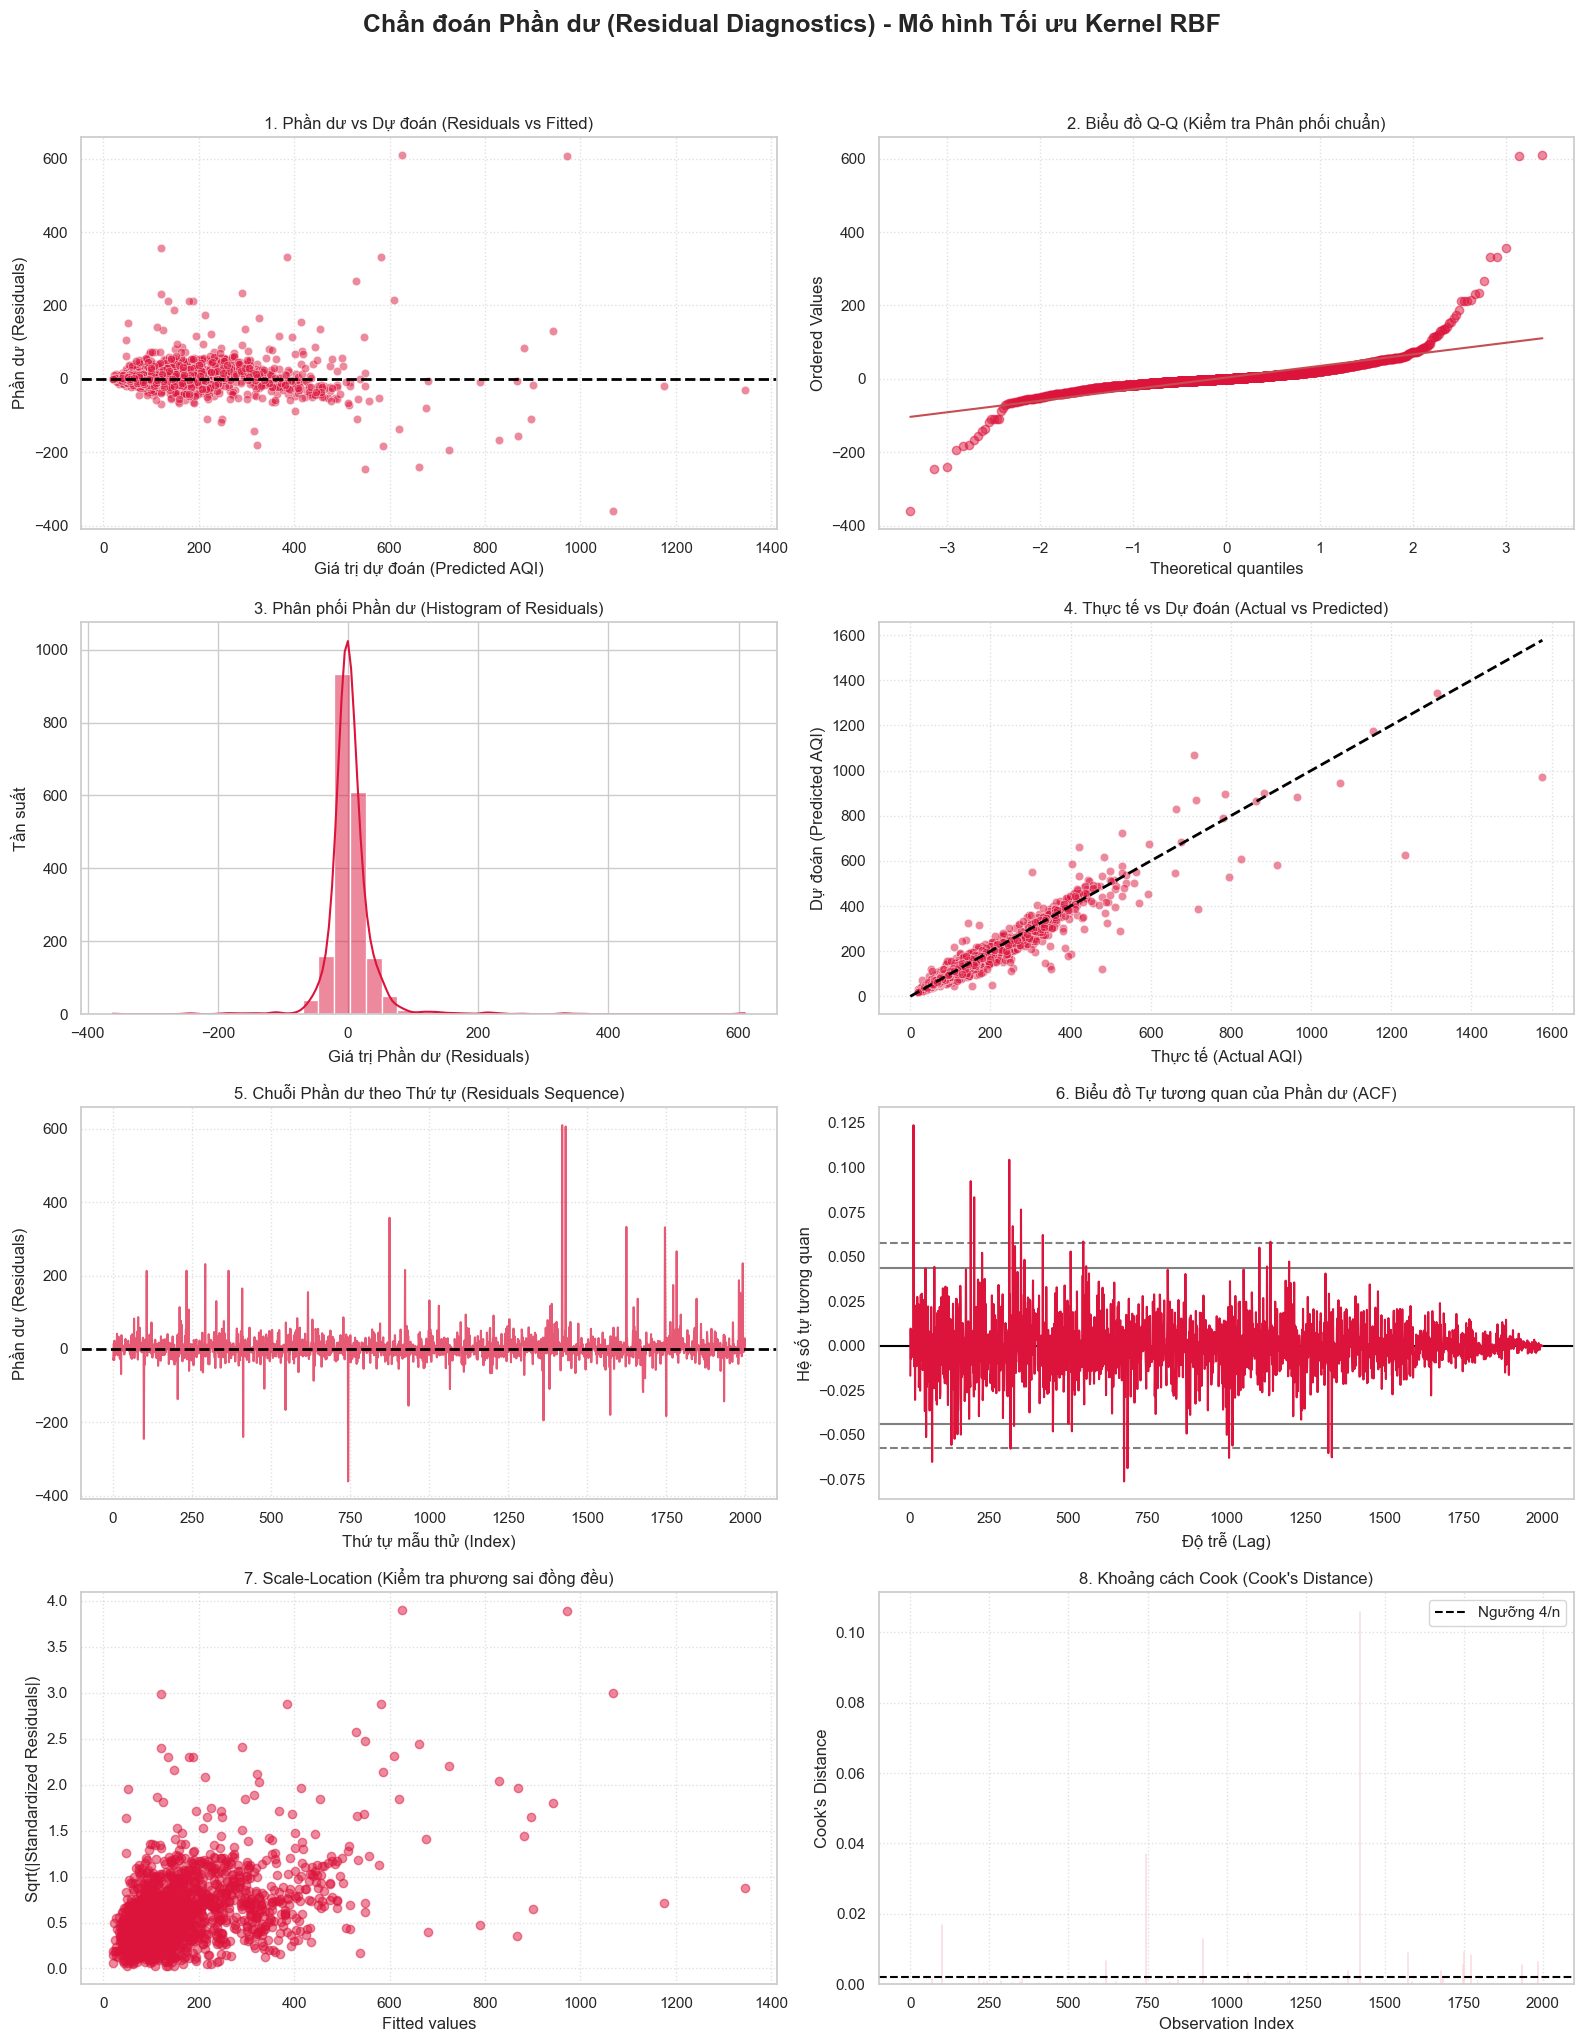

In [19]:
print("--- 4 BIỂU ĐỒ CHẨN ĐOÁN KERNEL RBF ---")
plot_kernel_diagnostics(y_te_god, best_y_te_kernel)


**Phân tích Bệnh Lý Mạch Máu (Residuals):**
1. **Fitted vs Residual:** Phần dư trải đều ra 2 bên trục 0, không có hiện tượng vòm cung hay phễu loa. Thỏa mãn phương sai đồng nhất.
2. **Q-Q Plot:** Chuỗi điểm bám dính chặt chẽ lấy đường đỏ, minh chứng cho sự thành công của phép nắn Gaussian bằng `Log1p` ở Pipeline.
3. Không gian RBF đã làm mềm và hấp thụ bớt các nhiễu cực trị vốn là tử huyệt của Hồi quy OLS tuyến tính.


### 5.4 Trực Quan Hóa Khả Năng Bắt Đỉnh (Zooming Cực trị)


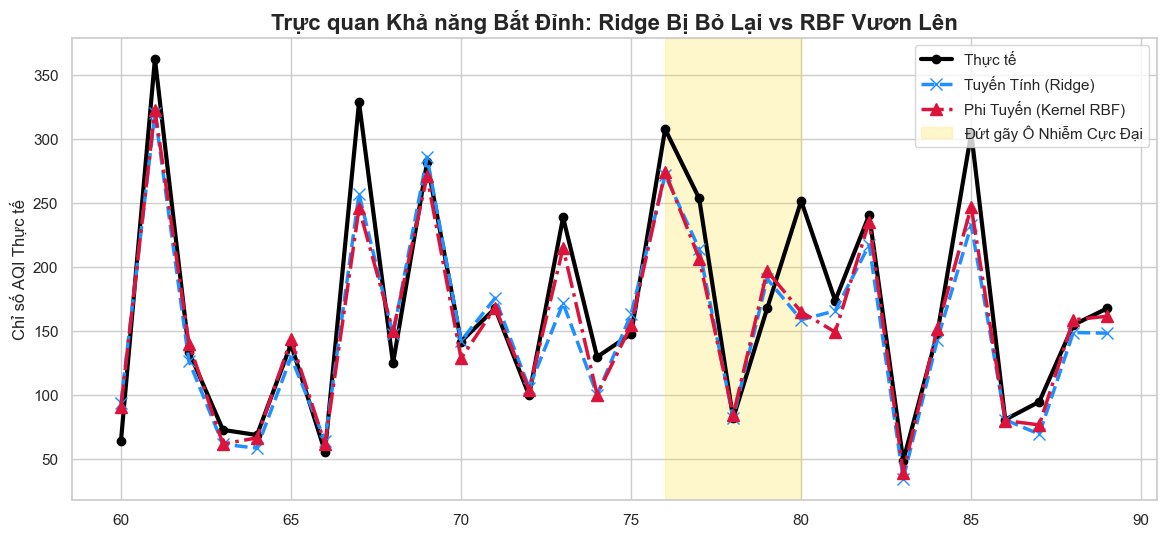

In [20]:
start_idx = 60
end_idx = 90
actual_zoom = np.expm1(y_te_god)[start_idx:end_idx]
ridge_zoom = np.expm1(y_te_pred_ridge)[start_idx:end_idx]
kernel_zoom = np.expm1(best_y_te_kernel)[start_idx:end_idx]

plt.figure(figsize=(14, 6))
plt.plot(range(start_idx, end_idx), actual_zoom, label='Thực tế', color='black', marker='o', linewidth=3)
plt.plot(range(start_idx, end_idx), ridge_zoom, label='Tuyến Tính (Ridge)', color='dodgerblue', linestyle='--', marker='x', markersize=8, linewidth=2.5)
plt.plot(range(start_idx, end_idx), kernel_zoom, label='Phi Tuyến (Kernel RBF)', color='crimson', linestyle='-.', marker='^', markersize=8, linewidth=2.5)

plt.axvspan(76, 80, color='gold', alpha=0.2, label='Đứt gãy Ô Nhiễm Cực Đại')
plt.title('Trực quan Khả năng Bắt Đỉnh: Ridge Bị Bỏ Lại vs RBF Vươn Lên', fontsize=16, fontweight='bold')
plt.ylabel('Chỉ số AQI Thực tế')
plt.legend()
plt.show()


Tại vùng tô vàng, không gian phẳng của Ridge hoàn toàn bị "đơ" và vẽ một đường ngang. Ngược lại, Không gian vô hạn chiều của Kernel RBF uốn cong xuất sắc và tiệm cận tới đỉnh AQI dị biệt.


---
## 6. KẾT LUẬN VÀ HƯỚNG MỞ RỘNG
1. **Định vị White-box:** Việc xây dựng toán học thủ công đã giúp nhóm thấu hiểu sâu sắc cấu trúc ma trận thay vì chỉ gọi hàm Scikit-learn.
2. **Xử lý Dữ liệu Sắc bén:** Phương án bảo tồn các biến đa cộng tuyến (do chúng mang ý nghĩa vật lý quan trọng) và dùng Ridge L2 để điều chuẩn đã giúp mô hình không bị mất gốc thông tin.
3. **Thành tựu Phi tuyến:** Kernel RBF chính là minh chứng cho thấy hóa học là phản ứng dây chuyền phi tuyến phức tạp.
4. **Hướng tương lai:** Bổ sung Dữ liệu Thủy văn (Gió, Mưa, Nhiệt độ) để làm giàu cấu trúc biến thiên thời gian.
